# GFDL horizontal biases: forced-ocean parameterization comparison

Time-mean temperature and salinity bias (`model - WOA18`) and response maps
for GFDL's 4 forced-ocean experiments, on GFDL's own native 1x1 degree grid
(kept untouched -- see [`gfdl_shim.py`](../gfdl_shim.py)). WOA-2018 is
interpolated onto this same grid once by
[`regrid_obs_to_gfdl_grid.py`](../regrid_obs_to_gfdl_grid.py) (from CESM's
tx2_3v2 grid), so the bias fields read directly from
`*_thetao_time_mean.nc`/`*_so_time_mean.nc` (generated by
`mom6_tools.TS_levels`, unmodified) are already on a shared grid.

Same style as CESM's `horizontal_biases.ipynb`: column 1 is always
`CTRL - WOA18`; every other column is that experiment's **response relative
to CTRL** (`exp - CTRL`), using the same `RdYlBu_r`/neutral-banded colormaps,
discrete `BoundaryNorm` levels, and `mom6_tools.m6plot.myStats`-based RMSE
(always the bias vs WOA18, even on response panels) as the CESM version.

**Averaging window: 1988-2012** (24 years), mirroring the CESM convention in
`forced_noGM.yaml` (model years 31-55), translated via GFDL's real-calendar
epoch (year 1 = 1958). This window is entirely after the `CTRL`/`bANN` branch
point (Jan 1983 -- `bANN`'s data is bit-identical to `CTRL`'s before that date),
so it doesn't dilute `bANN`'s signal with years where its parameterization
wasn't yet active.

**Scope**: `thetao`/`so` only, following [`gfdl_time_series.ipynb`](gfdl_time_series.ipynb)
(which still covers each experiment's full available record, not just this window).

**Kernel:** `env-from-npl-2024a` (Python 3.11.6).


In [1]:
%load_ext autoreload
%autoreload 2

import warnings
warnings.filterwarnings('ignore')

import os

import numpy as np
import xarray as xr
import matplotlib as mpl
import matplotlib.pyplot as plt
import gsw
import nc_time_axis  # lets matplotlib plot GFDL's cftime (julian calendar) axis directly
from mom6_tools.m6plot import myStats

from experiment import Experiment

# mom6_tools.m6plot forces matplotlib.use('Agg') at import time (for headless
# HPC batch plotting) -- this silently overrides Jupyter's own inline backend,
# so plt.show() below would otherwise produce no output at all, with no error.
%matplotlib inline

plt.rcParams['figure.figsize'] = (15, 5)
plt.rcParams.update({'font.size': 16})

# Repo-root-relative paths (this notebook lives in <repo>/notebooks)
REPO = os.path.abspath(os.path.join(os.getcwd(), '..'))
YAML_DIR = os.path.join(REPO, 'yamls')
GFDL_DIR = os.path.join(REPO, 'data', 'gfdl_1988_2012')

print('REPO     =', REPO)
print('YAML_DIR =', YAML_DIR)
print('GFDL_DIR =', GFDL_DIR)


ERROR 1: PROJ: proj_create_from_database: Open of /glade/work/pavelp/conda-envs/env-from-npl-2024a/share/proj failed


Basemap module not found. Some regional plots may not function properly
REPO     = /glade/u/home/pavelp/m2lines-CESM3-diagnostics
YAML_DIR = /glade/u/home/pavelp/m2lines-CESM3-diagnostics/yamls
GFDL_DIR = /glade/u/home/pavelp/m2lines-CESM3-diagnostics/data/gfdl_1988_2012


## Initialize experiments (read-only)

Each experiment is defined by its `name`, the diagnostics YAML config, and the
folder holding its postprocessed NetCDF files. Initialization is read-only: it
only reads config + grid, and never triggers heavy computation.

Layout follows CESM's `horizontal_biases.ipynb`/`vertical_sections.ipynb`
convention -- the CTRL panel is always `CTRL - WOA18` (the control's own bias
against observations), and every other panel is that experiment's **response
relative to CTRL** (`exp - CTRL`), not a second bias-vs-obs map. Panels are
arranged 2x2 (CTRL/bANN top row, uANN/bANN_uANN bottom row) rather than
CESM's 2x3 (coupled/forced) or a single row, since GFDL has 4 forced-ocean
experiments (`bANN`, `uANN`, and `bANN_uANN` all responding independently to
`CTRL`) and no coupled runs.

In [2]:
# (name, folder) for each experiment. YAML config is yamls/<name>.yaml
experiment_defs = [
    ('gfdl_CTRL',       GFDL_DIR),
    ('gfdl_bANN',       GFDL_DIR),
    ('gfdl_uANN',       GFDL_DIR),
    ('gfdl_bANN_uANN',  GFDL_DIR),
]

exps = {}
for name, folder in experiment_defs:
    yaml_path = os.path.join(YAML_DIR, f'{name}.yaml')
    exps[name] = Experiment(yaml_path, folder=folder, name=name,
                            load_grid=True, verbose=True)

names = list(exps.keys())
CTRL = 'gfdl_CTRL'   # response baseline for every non-CTRL column

# Short legend labels
LABELS = {
    'gfdl_CTRL':      'CTRL',
    'gfdl_bANN':      'bANN',
    'gfdl_uANN':      'uANN',
    'gfdl_bANN_uANN': 'bANN_uANN',
}

print('Initialized:', names)


[gfdl_CTRL] casename=gfdl_CTRL, rundir=/glade/derecho/scratch/pavelp/GFDL/CTRL/cesm_format/run
MOM6 grid successfully loaded... 

[gfdl_bANN] casename=gfdl_bANN, rundir=/glade/derecho/scratch/pavelp/GFDL/bANN/cesm_format/run
MOM6 grid successfully loaded... 

[gfdl_uANN] casename=gfdl_uANN, rundir=/glade/derecho/scratch/pavelp/GFDL/uANN/cesm_format/run
MOM6 grid successfully loaded... 

[gfdl_bANN_uANN] casename=gfdl_bANN_uANN, rundir=/glade/derecho/scratch/pavelp/GFDL/bANN_uANN/cesm_format/run
MOM6 grid successfully loaded... 

Initialized: ['gfdl_CTRL', 'gfdl_bANN', 'gfdl_uANN', 'gfdl_bANN_uANN']


# 1. Mixed-layer depth (MLD) bias and response

Winter and summer mixed-layer depth bias (`model $-$ obs`) and response
(`exp $-$ CTRL`), in the same 2x2 (CTRL/bANN top row, uANN/bANN_uANN bottom
row) map style as the temperature/salinity sections below. Observed MLD is
the de Boyer Montegut (2023) climatology, interpolated onto GFDL's own native
grid (see `regrid_mld_obs_to_gfdl_grid.py`), with winter/summer constructed
per hemisphere (NH winter = JFM, SH winter = JAS, and vice-versa for summer)
-- the same convention CESM's `horizontal_biases.ipynb` Section 1 uses, and
the same one `gfdl_mld.py` applies to the model output itself (matching
`mom6_tools.surface.get_MLD`'s definition).

Model MLD comes from GFDL's own online-diagnosed `MLD_003` (density-threshold
mixed layer depth) -- there is no GFDL equivalent for `mom6_tools.surface`'s
required `SSU`/`SSV`/`speed` (surface currents), so that script cannot be
reused unmodified here; see `gfdl_mld.py`'s module docstring for the full
reasoning. The CTRL panel shows the CTRL bias (`model - obs`); the other 3
panels show each experiment's response (`exp - CTRL`). RMSE is always the
area-weighted RMS of `model - obs`.

In [6]:
# --- Section 1: winter/summer mixed-layer depth (MLD) bias and response ---
# Observed MLD: de Boyer Montegut (2023) climatology, already interpolated
# onto GFDL's own native grid (data/gfdl_obs/mld_deboyer_2023_on_gfdl_grid.nc,
# see regrid_mld_obs_to_gfdl_grid.py) -- so, unlike CESM's version of this
# section, no further regridding is needed here, just the same
# hemisphere-dependent JFM/JAS split (NH winter = JFM, SH winter = JAS, and
# the reverse for summer) applied to the observational climatology.
_mld_obs = xr.open_dataset(os.path.join(REPO, 'data', 'gfdl_obs',
                                        'mld_deboyer_2023_on_gfdl_grid.nc'))

_grd = exps[CTRL].grd
_j = int(np.abs(_grd.yh.values - 0.0).argmin())      # row nearest the equator
_obs_JFM = _mld_obs.mld.isel(time=[0, 1, 2]).mean('time').values
_obs_JAS = _mld_obs.mld.isel(time=[6, 7, 8]).mean('time').values
obs_mld_winter = _obs_JAS.copy()
obs_mld_summer = _obs_JAS.copy()
obs_mld_winter[_j:, :] = _obs_JFM[_j:, :]    # NH winter = JFM (SH winter = JAS)
obs_mld_summer[:_j, :] = _obs_JFM[:_j, :]    # SH summer = JFM (NH summer = JAS)

# Bias-map levels/colormap for MLD (matches CESM's horizontal_biases.ipynb).
# Summer MLD is much shallower, so it uses a tighter +/-20 m scale (vs +/-200 m
# for winter).
MLD_CMAP = plt.get_cmap('RdBu_r')
MLD_WINTER_LEVELS = np.linspace(-100, 100, 17)   # m
MLD_SUMMER_LEVELS = np.linspace(-10, 10, 17)     # m
MLD_WINTER_NORM = mpl.colors.BoundaryNorm(MLD_WINTER_LEVELS, MLD_CMAP.N, extend='both')
MLD_SUMMER_NORM = mpl.colors.BoundaryNorm(MLD_SUMMER_LEVELS, MLD_CMAP.N, extend='both')


def plot_bias_maps_2d(get_model, obs, norm, cmap, quantity, unit, cbar_label):
    """2x2 map of a 2D bias field (model - obs) and exp - CTRL response
    patterns (CTRL/bANN top row, uANN/bANN_uANN bottom row). Mirrors
    ``plot_bias_maps`` but for a field with no depth level (``get_model(exp)``
    returns the model's (yh, xh) DataArray; ``obs`` is the matching (yh, xh)
    observational array, shared across all 4 panels)."""
    fig, axes = plt.subplots(2, 2, figsize=(14, 12), dpi=120,
                             sharex=True, sharey=True, constrained_layout=True)
    pc = None
    ctrl_bias = get_model(exps[CTRL]) - obs
    for i, name in enumerate(names):
        row, col = divmod(i, 2)
        ax = axes[row, col]
        exp = exps[name]
        bias = get_model(exp) - obs
        if i == 0:
            field = bias                       # CTRL bias (model - obs)
            title = f'{LABELS[name]} ' + r'$-$' + ' de Boyer 2023'
        else:
            field = bias - ctrl_bias           # response pattern (exp - CTRL)
            title = f'{LABELS[name]} ' + r'$-$' + ' CTRL'
        area = np.ma.masked_invalid(exp.area.values)
        _, _, _, _, rmse = myStats(np.ma.masked_invalid(bias), area)
        field_masked = np.where(exp.grd.wet.values > 0, field, np.nan)
        pc = ax.pcolormesh(exp.grd.xh.values, exp.grd.yh.values,
                           np.ma.masked_invalid(field_masked),
                           cmap=cmap, norm=norm, shading='auto')
        ax.set_facecolor('gray')
        ax.set_title(f'{title}\nRMSE={rmse:.1f} {unit}')
        if row == 1:
            ax.set_xlabel('Longitude')
        if col == 0:
            ax.set_ylabel('Latitude')
    cbar = fig.colorbar(pc, ax=axes, label=cbar_label, extend='both',
                        ticks=norm.boundaries, spacing='uniform',
                        shrink=0.85, pad=0.02)
    cbar.ax.set_yticklabels([f'{b:g}' for b in norm.boundaries])
    fig.suptitle(f'{quantity} bias (model $-$ de Boyer 2023) and response patterns',
                 fontsize=26)
    plt.show()


def plot_mld_winter():
    plot_bias_maps_2d(lambda e: e.mld_winter().MLD_winter.values, obs_mld_winter,
                      MLD_WINTER_NORM, MLD_CMAP, 'Winter MLD', 'm',
                      'Winter MLD bias or response [m]')


def plot_mld_summer():
    plot_bias_maps_2d(lambda e: e.mld_summer().MLD_summer.values, obs_mld_summer,
                      MLD_SUMMER_NORM, MLD_CMAP, 'Summer MLD', 'm',
                      'Summer MLD bias or response [m]')

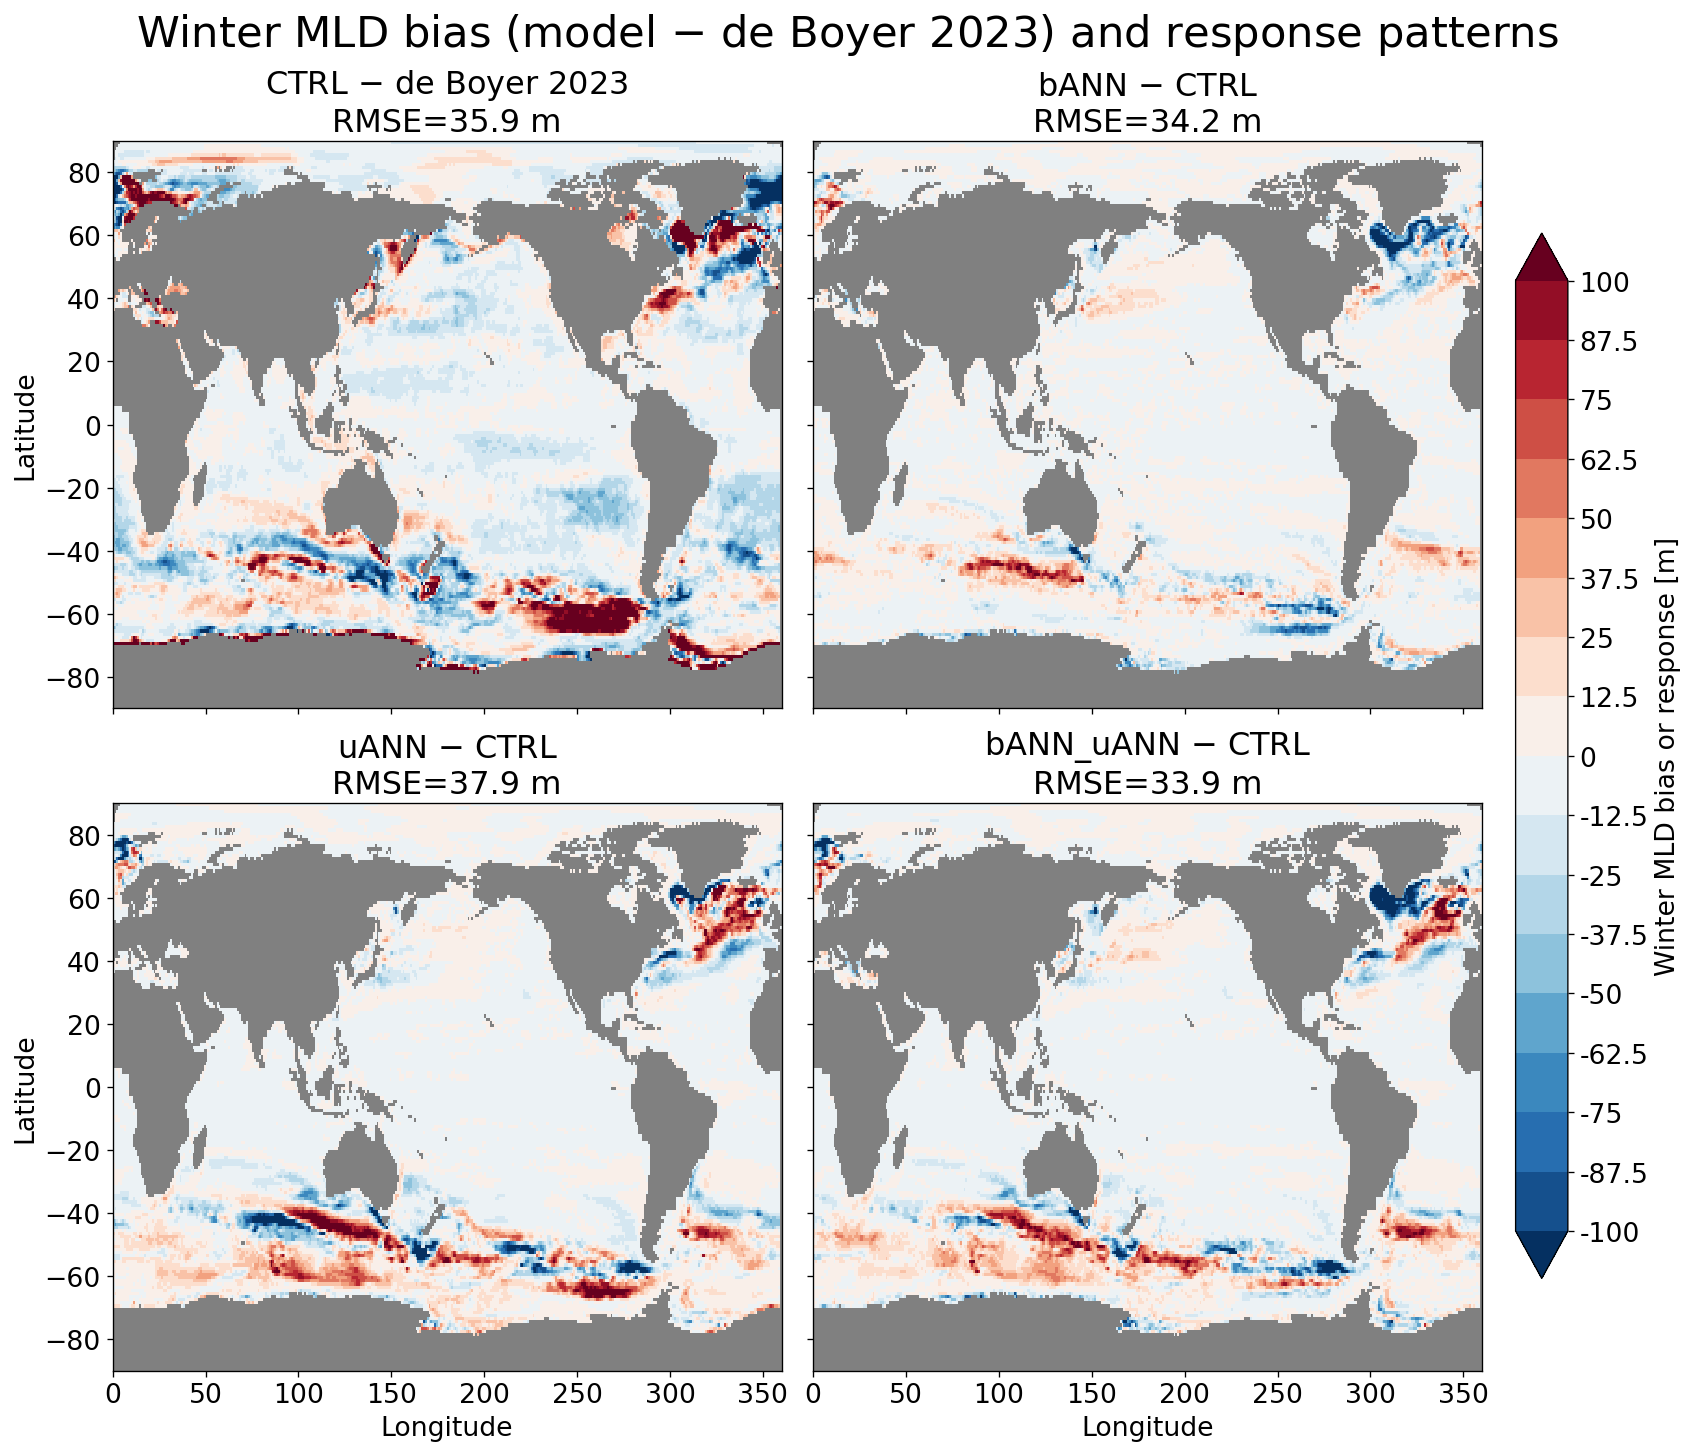

In [7]:
plot_mld_winter()

## Summer MLD

Same diagnostic for the summer season (SH summer = JFM, NH summer = JAS).

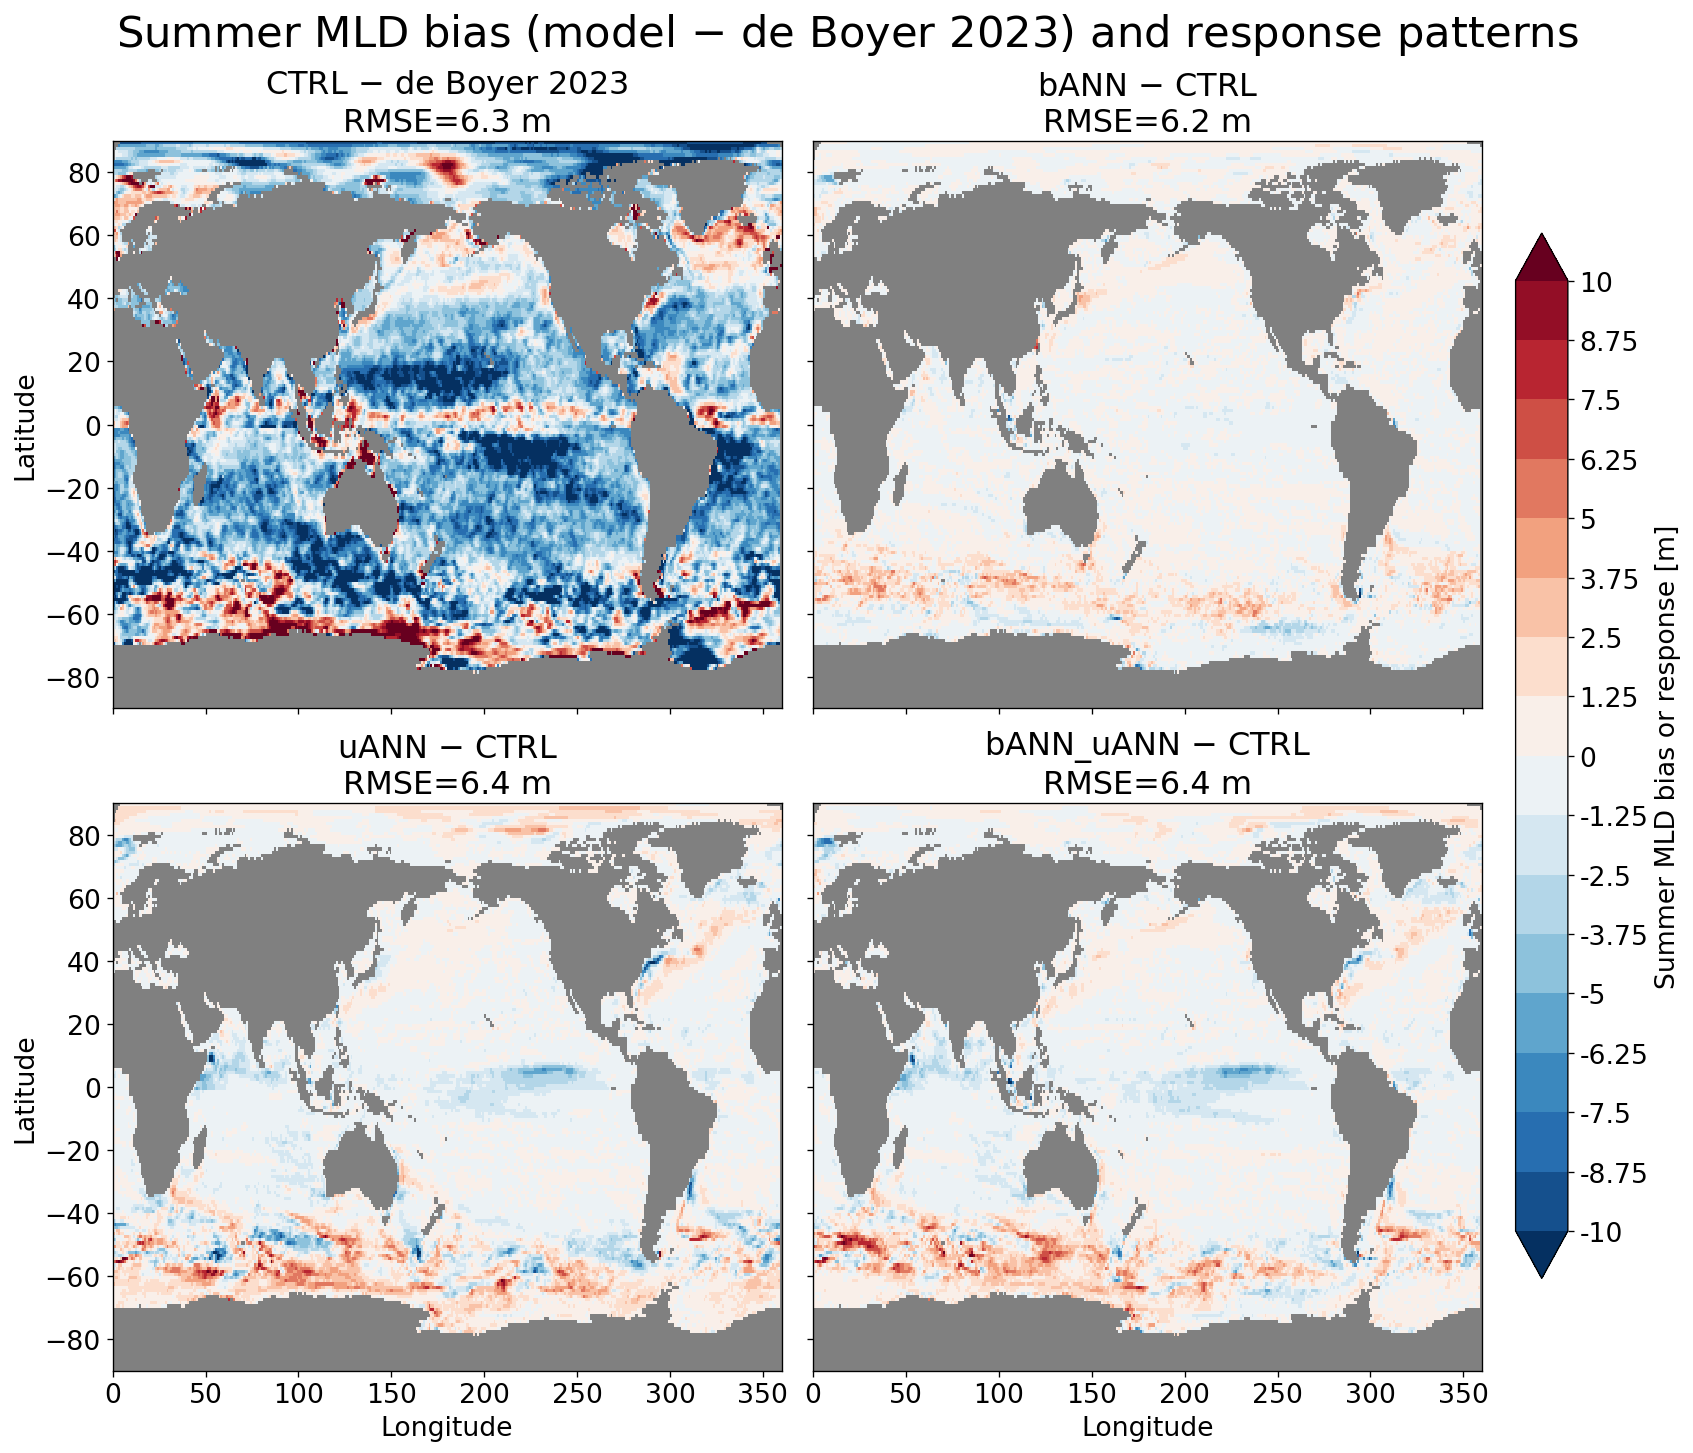

In [8]:
plot_mld_summer()

## Shared bias/response-map plotter

CTRL panel: `CTRL - WOA18`. Other 3 panels: response of `bANN`/`uANN`/`bANN_uANN`
relative to `CTRL` (`exp - CTRL`). RMSE is always the area-weighted RMS of
each experiment's own bias against WOA18 (`exp - WOA18`), even on the
response-displaying panels -- exactly matching CESM's `plot_bias_maps`.

In [6]:
def plot_bias_maps(get_bias, target_depth, norm, cmap, quantity, unit, cbar_label):
    """2x2 map of a bias field (model - WOA18) and exp - CTRL response patterns
    (CTRL/bANN top row, uANN/bANN_uANN bottom row).

    ``get_bias(exp)`` returns the 3D bias DataArray (z_l, yh, xh) for an
    experiment. The nearest ``z_l`` level to ``target_depth`` (m) is selected.
    RMSE is always the area-weighted RMS of each experiment's bias against
    WOA18 (exp - WOA18), even on panels that display the response pattern
    (exp - CTRL).
    """
    fig, axes = plt.subplots(2, 2, figsize=(14, 12), dpi=120,
                             sharex=True, sharey=True, constrained_layout=True)
    pc = None
    depth = None
    ctrl_bias = get_bias(exps[CTRL]).sel(z_l=target_depth, method='nearest')
    for i, name in enumerate(names):
        row, col = divmod(i, 2)
        ax = axes[row, col]
        exp = exps[name]
        bias = get_bias(exp).sel(z_l=target_depth, method='nearest')
        depth = round(float(bias.z_l), 1)
        if i == 0:
            field = bias                       # CTRL bias (model - WOA18)
            title = f'{LABELS[name]} ' + r'$-$' + ' WOA18'
        else:
            field = bias - ctrl_bias           # response pattern (exp - CTRL)
            title = f'{LABELS[name]} ' + r'$-$' + ' CTRL'
        area = np.ma.masked_invalid(exp.area.values)
        _, _, _, _, rmse = myStats(np.ma.masked_invalid(bias.values), area)
        # Plot against the clean 1D xh/yh axes, not the 2D geolon/geolat
        # fields. GFDL's grid is regular, so xh/yh ARE longitude/latitude
        # exactly -- and geolon in particular has its own native wrap
        # discontinuity (its cut point is not at the array boundary), which
        # breaks pcolormesh's assumption that 2D cell centers are
        # monotonic and produces degenerate quads (stripe artifacts, and
        # colors bleeding onto land at the wrap seam).
        field_masked = field.where(exp.grd.wet > 0)
        pc = ax.pcolormesh(exp.grd.xh.values, exp.grd.yh.values,
                           np.ma.masked_invalid(field_masked.values),
                           cmap=cmap, norm=norm, shading='auto')
        ax.set_facecolor('gray')
        ax.set_title(f'{title}\nRMSE={rmse:.2f} {unit}')
        if row == 1:
            ax.set_xlabel('Longitude')
        if col == 0:
            ax.set_ylabel('Latitude')
    cbar = fig.colorbar(pc, ax=axes, label=cbar_label, extend='both',
                        ticks=norm.boundaries, spacing='uniform',
                        shrink=0.85, pad=0.02)
    cbar.ax.set_yticklabels([f'{b:g}' for b in norm.boundaries])
    fig.suptitle(f'{quantity} bias (model $-$ WOA18) and response patterns, '
                 f'depth={depth} m', fontsize=26)
    plt.show()


# --- Temperature configuration (identical to CESM's horizontal_biases.ipynb) ---
TBIAS_LEVELS = np.arange(-1.8, 1.81, 0.4)   # degC
T_CMAP = plt.get_cmap('RdYlBu_r')
T_NORM = mpl.colors.BoundaryNorm(TBIAS_LEVELS, T_CMAP.N, extend='both')


def plot_thetao_bias_maps(target_depth):
    plot_bias_maps(lambda e: e.thetao().thetao_bias, target_depth,
                   T_NORM, T_CMAP, 'Temperature', r'$^\circ$C',
                   r'Temperature bias or response [$^\circ$C]')


# --- Salinity configuration (identical to CESM's horizontal_biases.ipynb) ---
# Wide neutral central bin: |bias| < 0.1 PSU is drawn as a single neutral
# color instead of flipping hue across zero.
SBIAS_LEVELS = np.array([-1.0, -0.8, -0.6, -0.4, -0.2, -0.1,
                         0.1, 0.2, 0.4, 0.6, 0.8, 1.0])   # PSU
_s_base = plt.get_cmap('RdYlBu_r')
_s_nbins = len(SBIAS_LEVELS) - 1
_s_colors = list(_s_base(np.linspace(0, 1, _s_nbins)))
_s_colors[_s_nbins // 2] = (1.0, 1.0, 1.0, 1.0)   # neutral for [-0.1, 0.1] PSU
S_CMAP = mpl.colors.ListedColormap(_s_colors)
S_CMAP.set_under(_s_base(0.0))
S_CMAP.set_over(_s_base(1.0))
S_NORM = mpl.colors.BoundaryNorm(SBIAS_LEVELS, S_CMAP.N)


def plot_so_bias_maps(target_depth):
    plot_bias_maps(lambda e: e.so().so_bias, target_depth,
                   S_NORM, S_CMAP, 'Salinity', 'PSU',
                   'Salinity bias or response [PSU]')

# 2. Temperature bias and response, surface

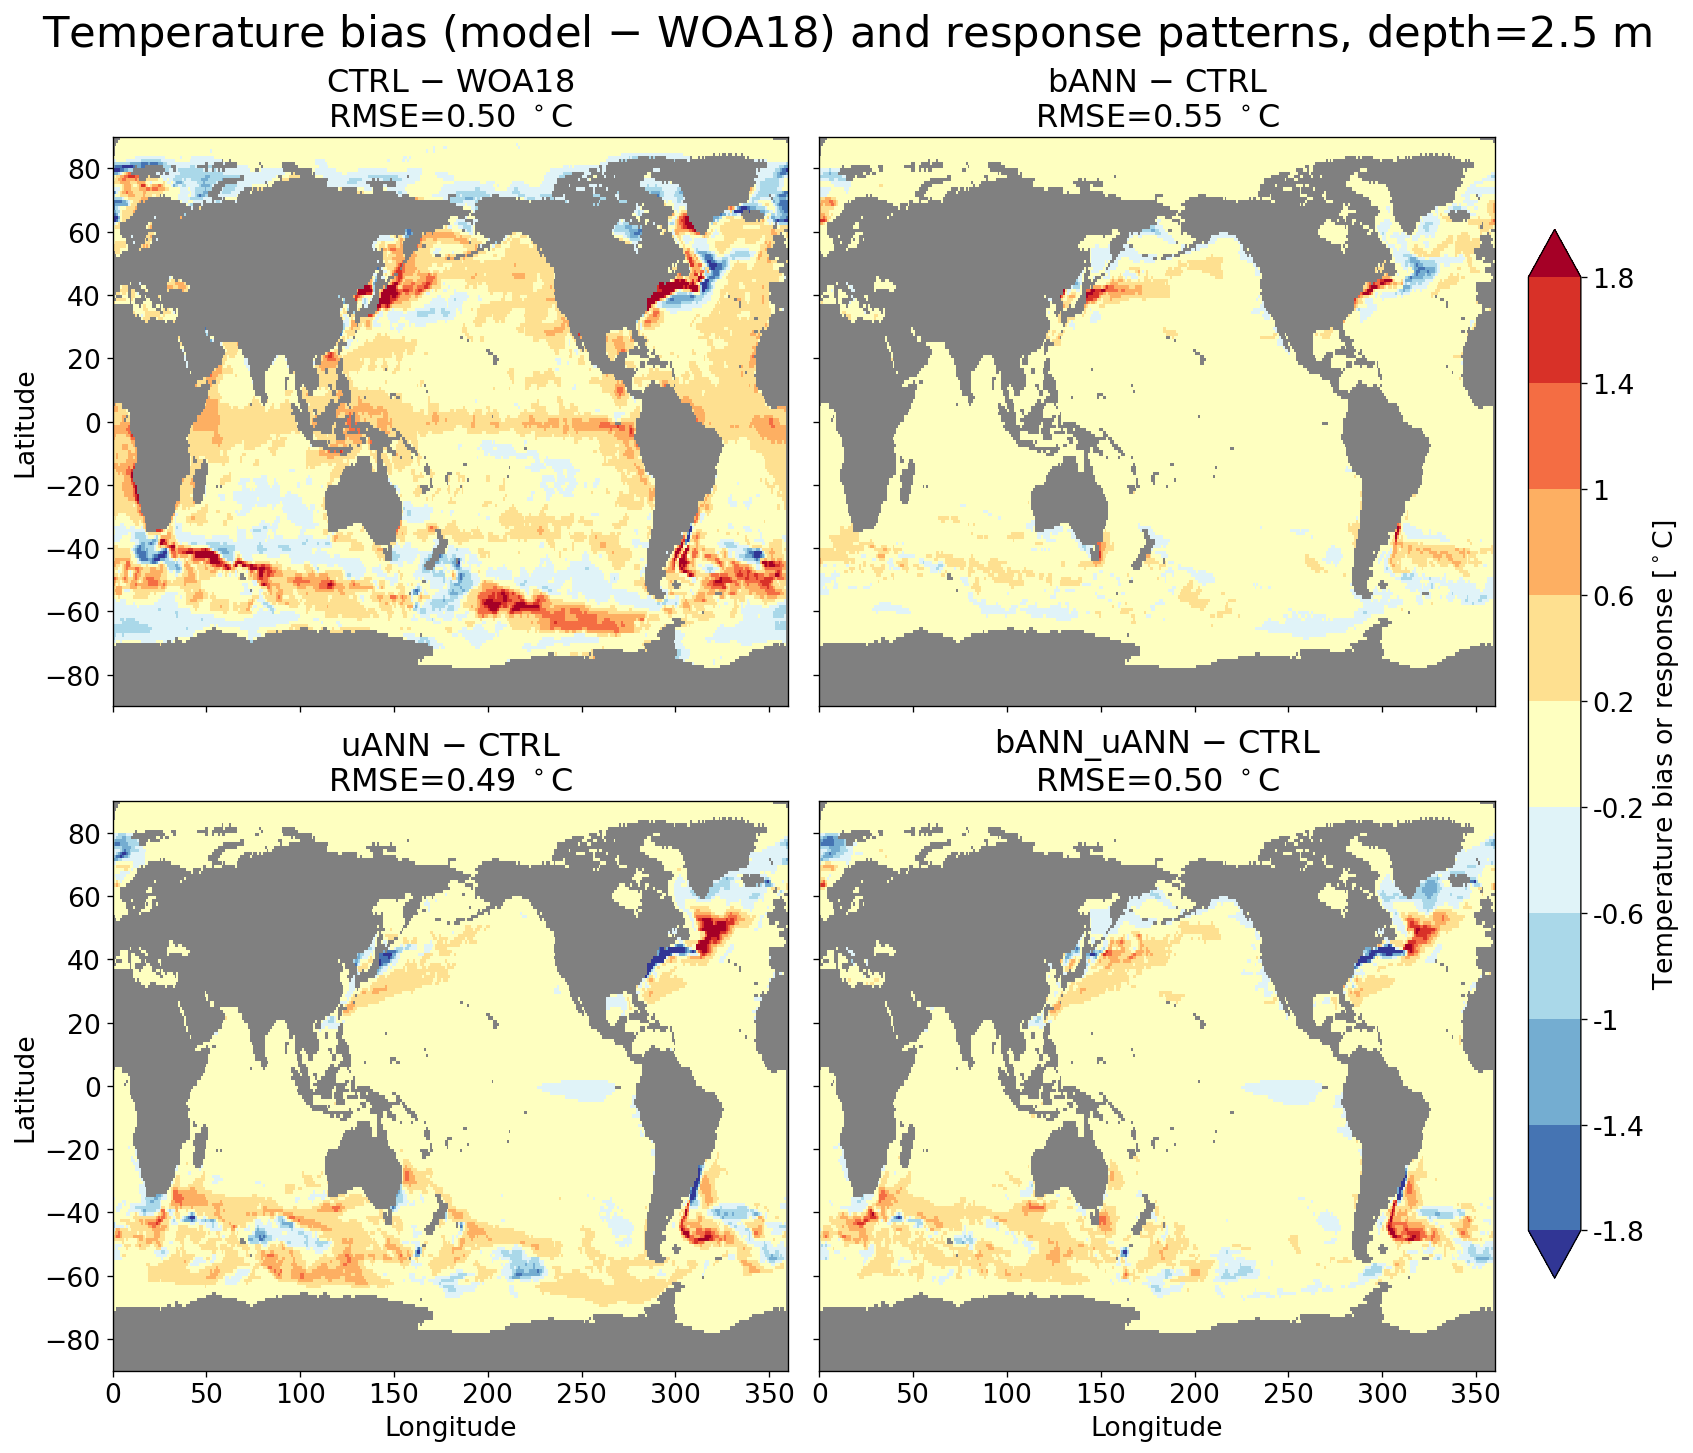

In [7]:
plot_thetao_bias_maps(2.5)   # surface (nearest z_l = 2.5 m)

# 3. Temperature bias and response, ~100 m

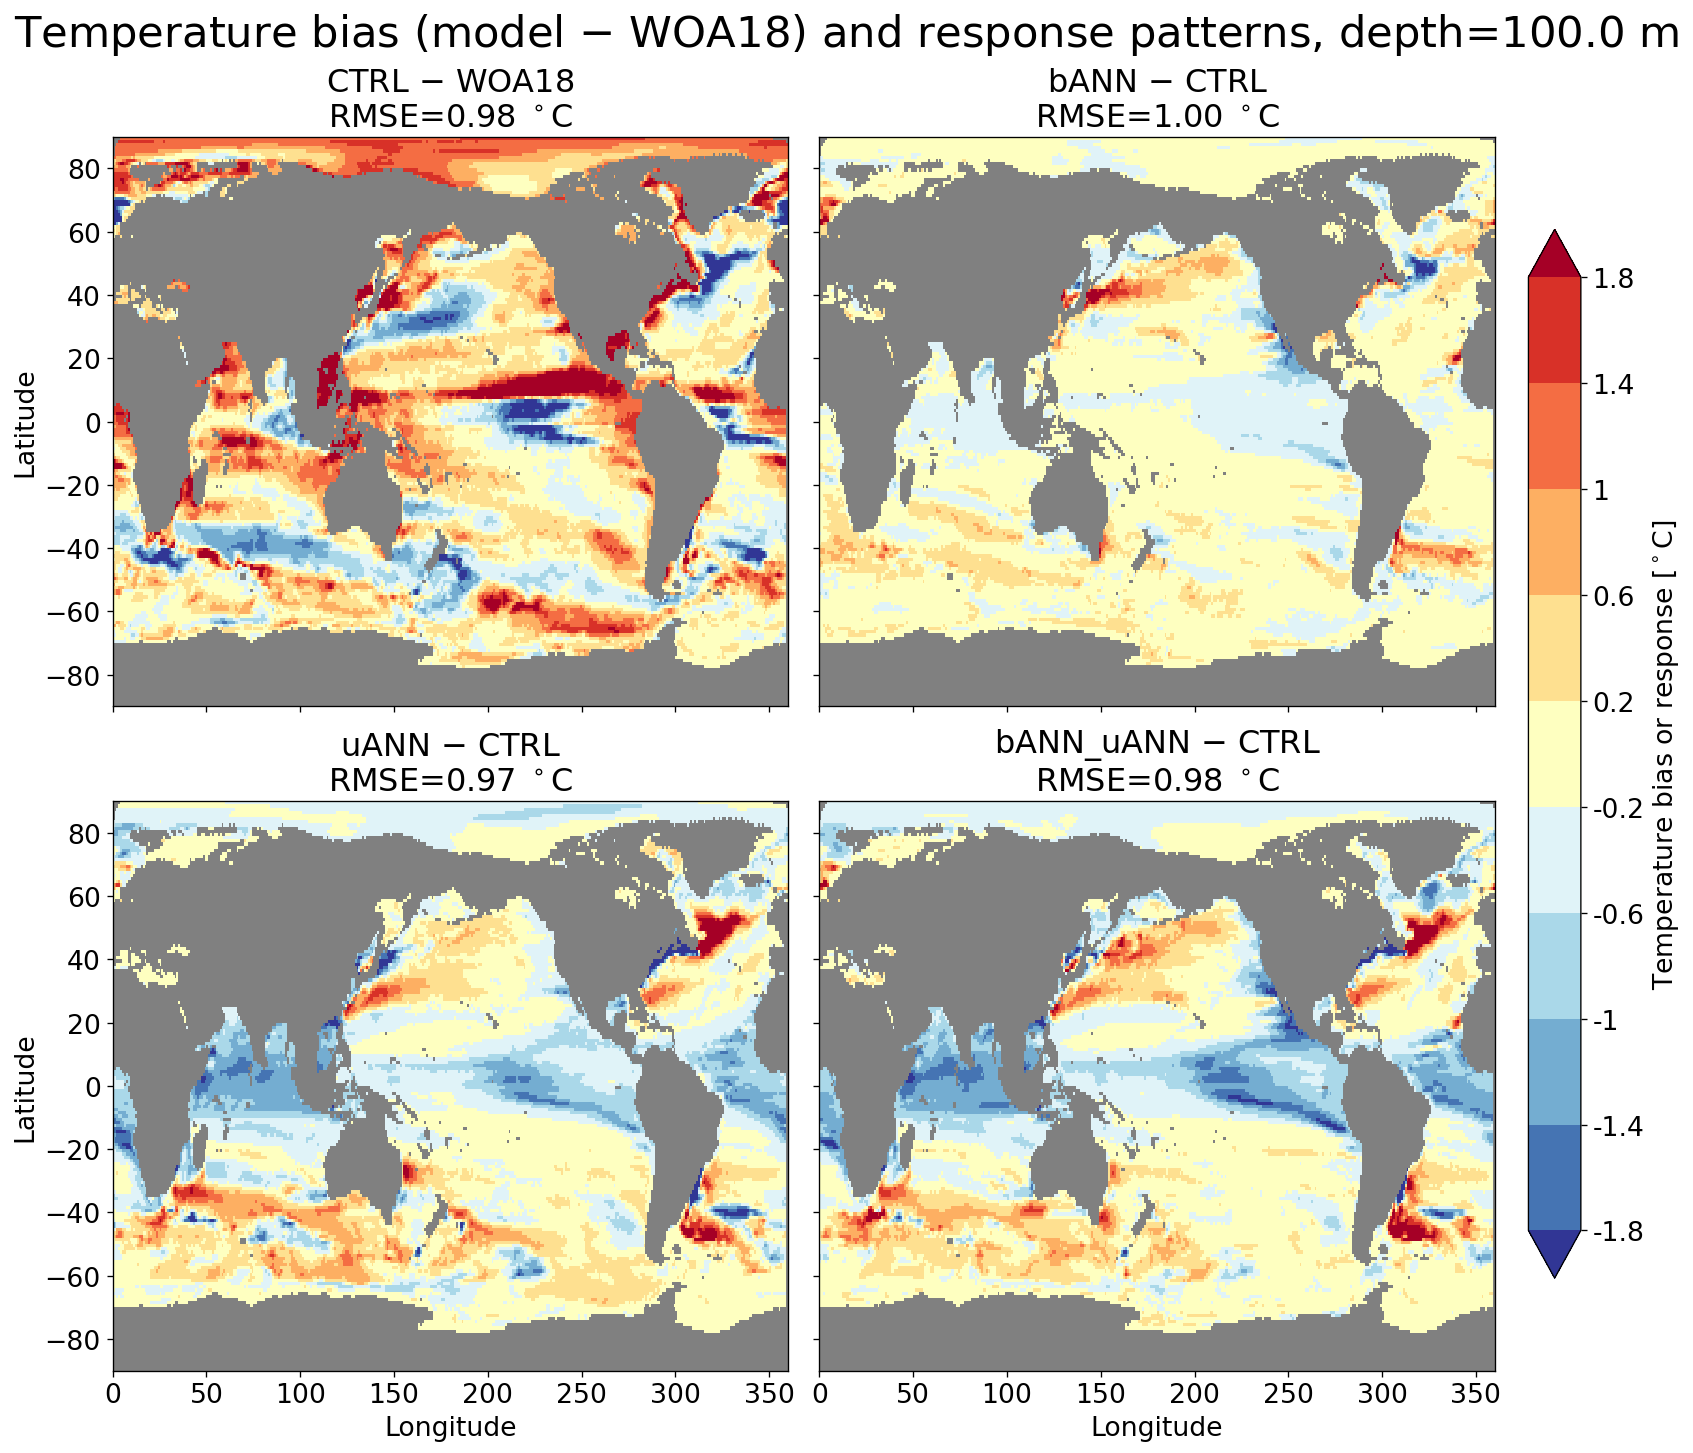

In [8]:
plot_thetao_bias_maps(100.0)   # nearest z_l to 100 m

# 4. Salinity bias and response, surface

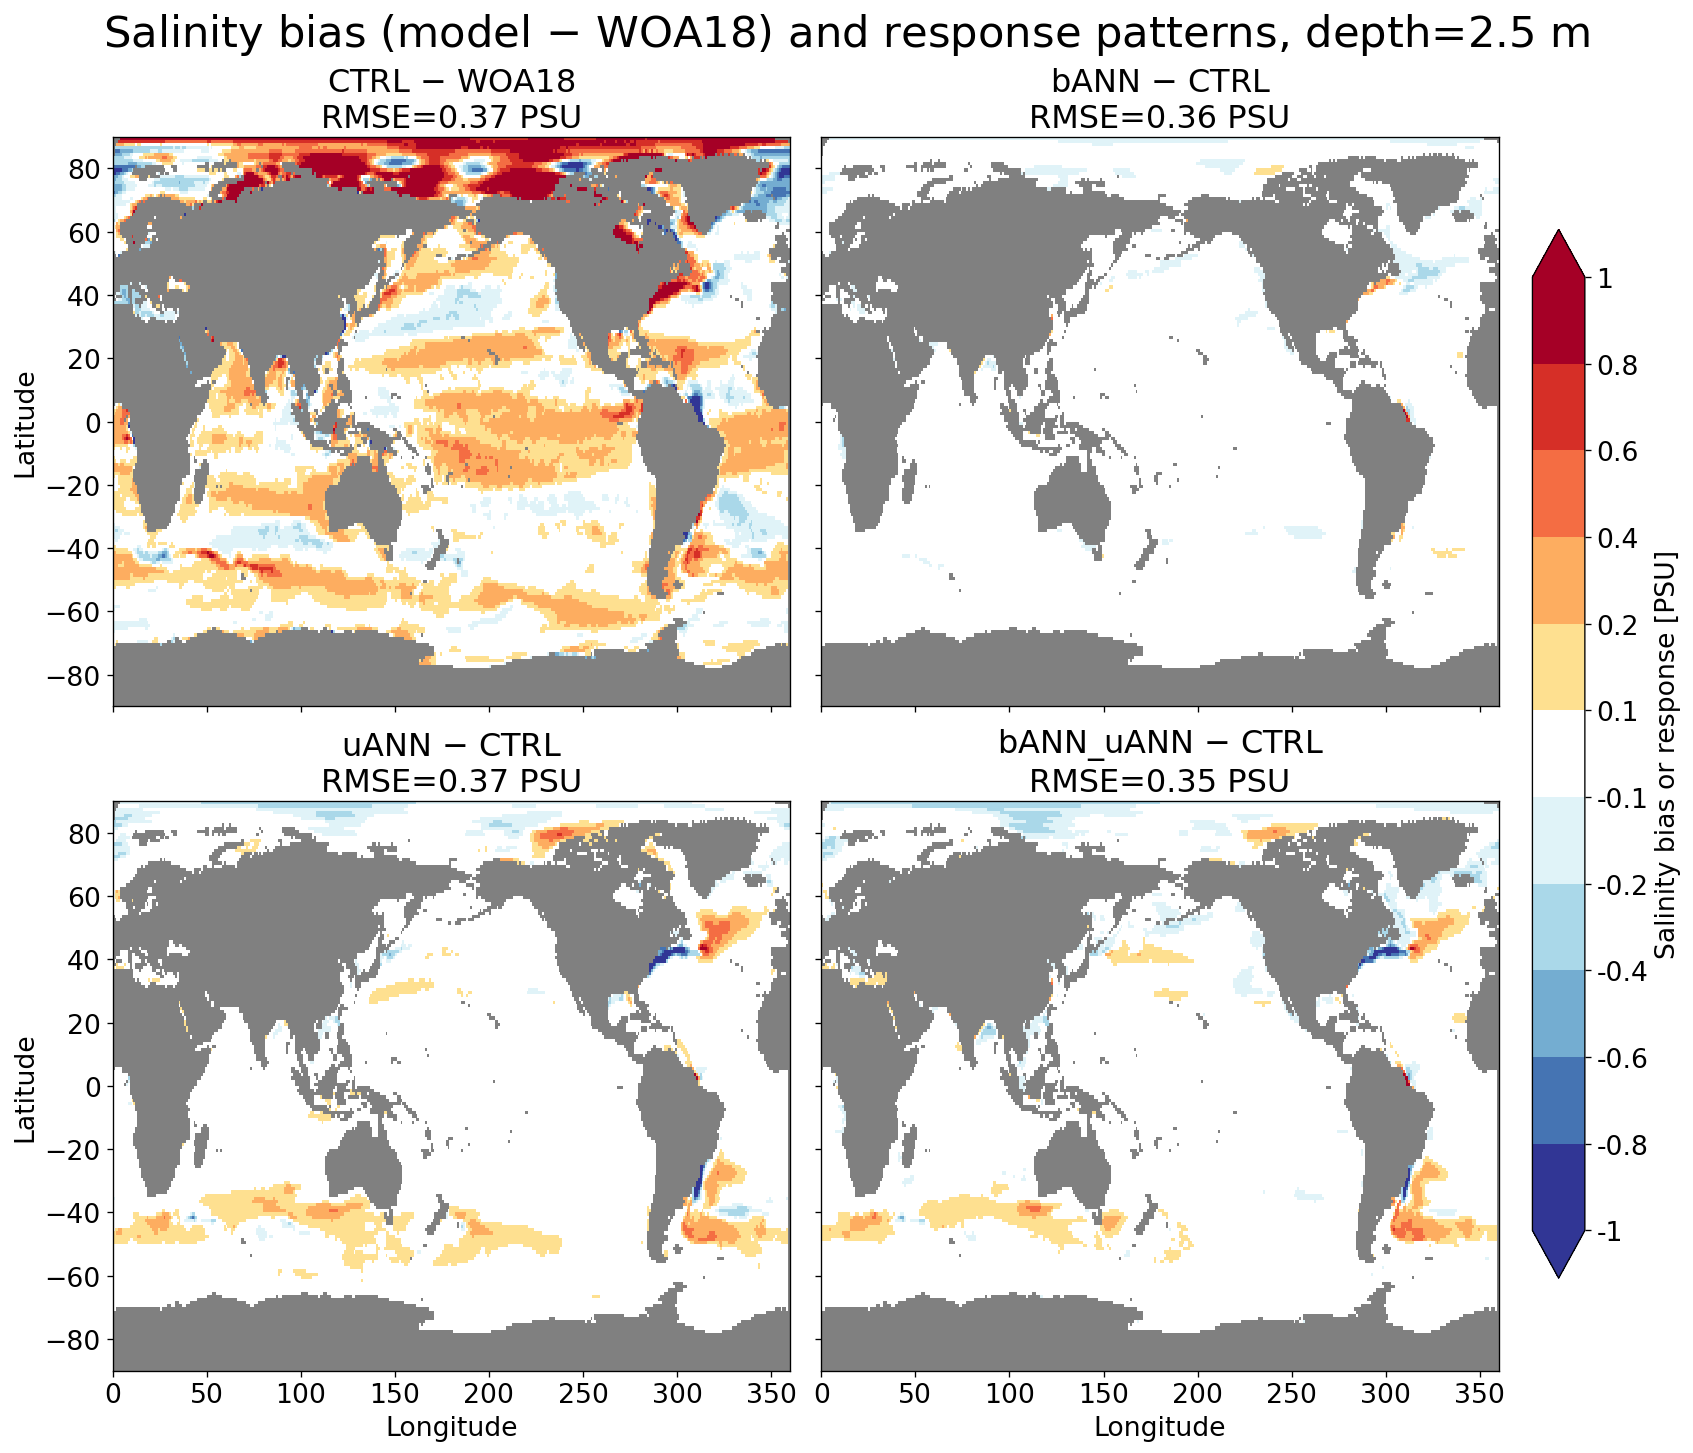

In [9]:
plot_so_bias_maps(2.5)   # surface (nearest z_l = 2.5 m)

# 5. Salinity bias and response, ~100 m

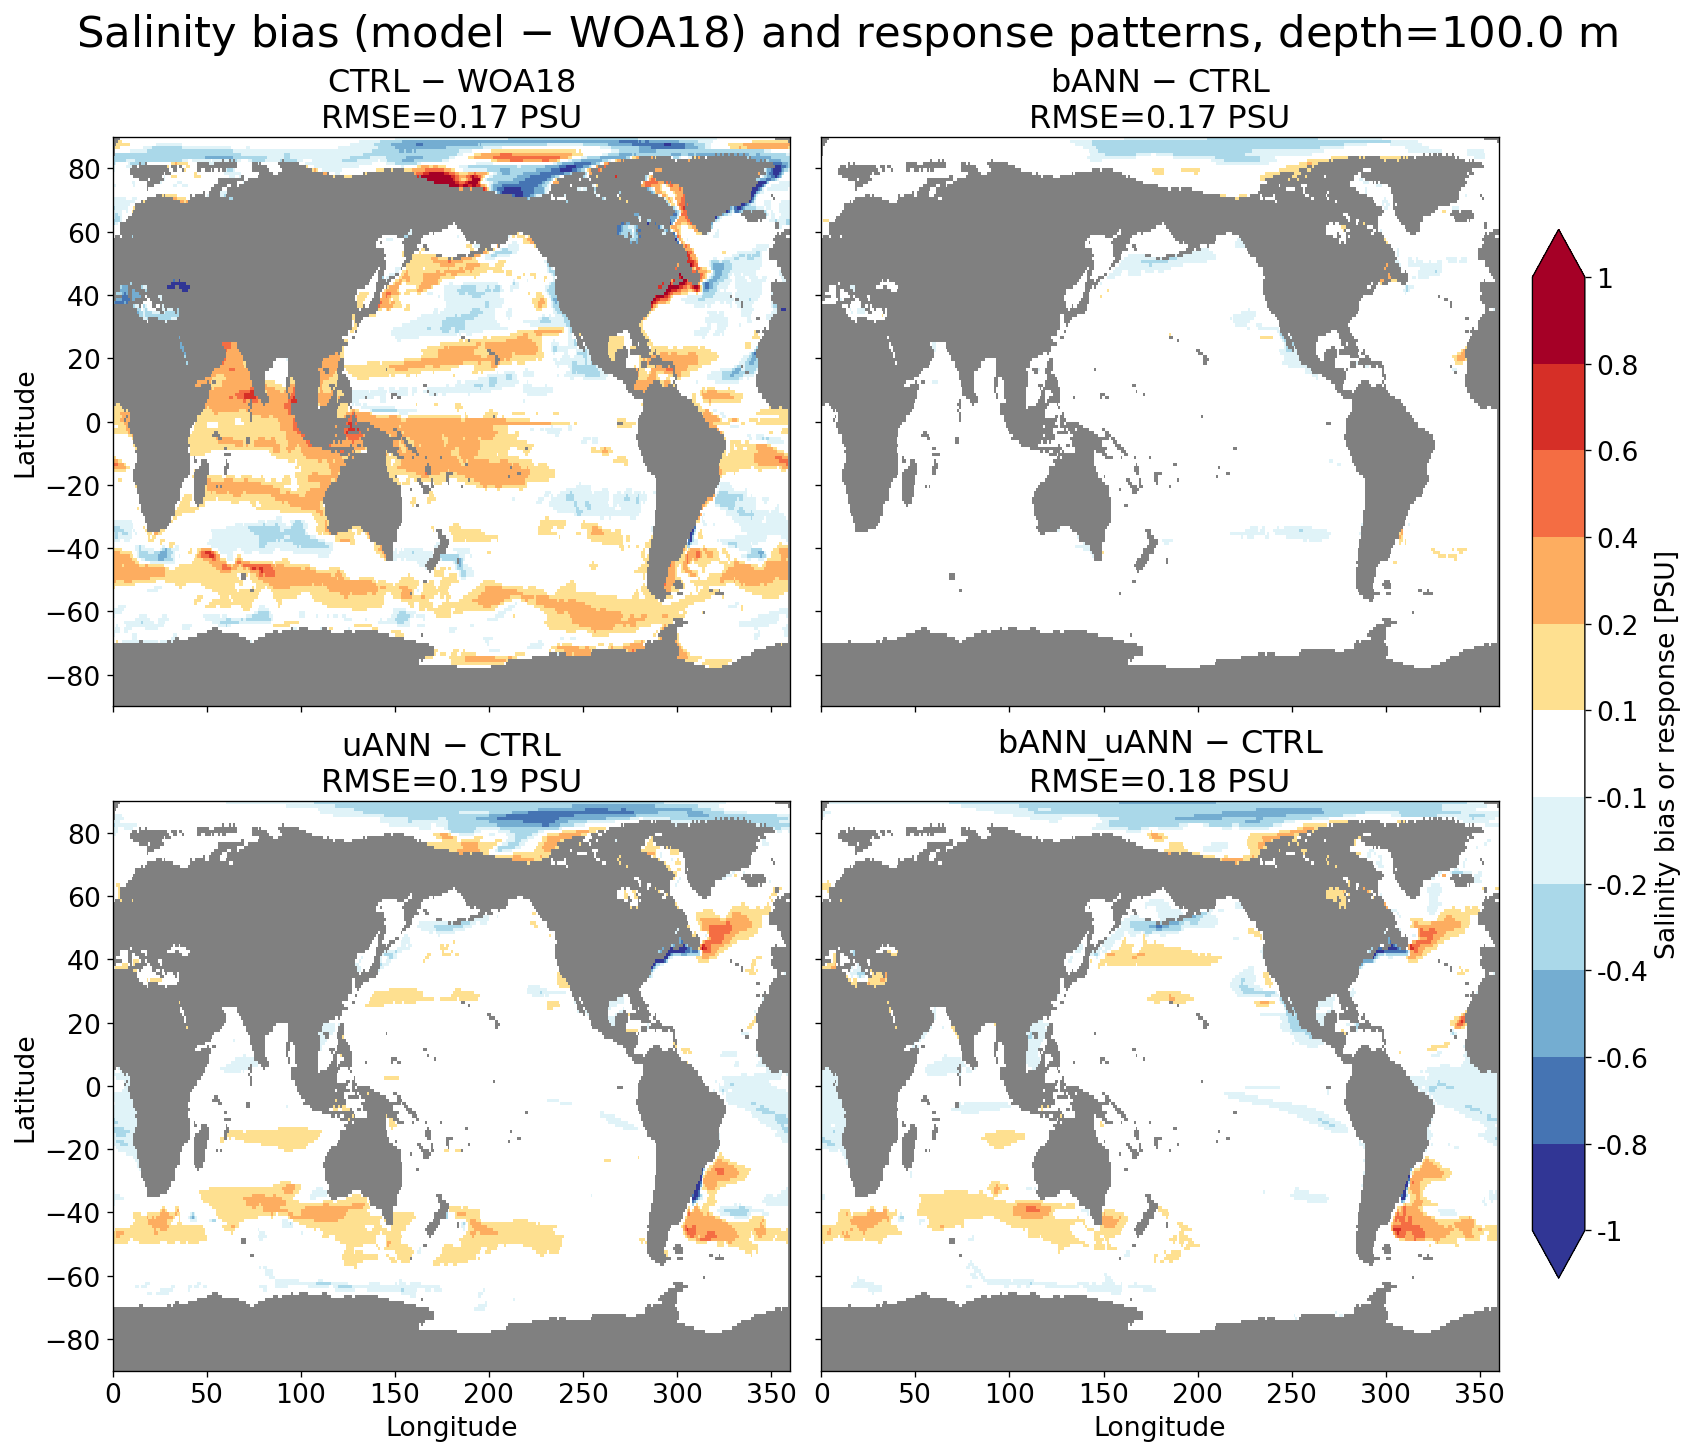

In [10]:
plot_so_bias_maps(100.0)   # nearest z_l to 100 m